# Поиск параметров ПИД-регулятора для стабилизации обратного маятника при помощи оптимизации роем частиц

Импортируем библиотеки

In [ ]:
!pip install scipy matplotlib

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Параметры:

In [ ]:
M = 0.5
m = 0.2
L = 0.3
g = 9.81

F_MAX = 15.0

T_FINAL = 20
N_POINTS = 2000

TIME = np.linspace(0, T_FINAL, N_POINTS)

Задаем функцию ПИД-регулятора и системы

In [ ]:
def pid(theta, omega, integral_theta,
        kp, ki, kd,
        f_max=15):

    F = -(kp * theta
          + ki * integral_theta
          + kd * omega)

    return np.clip(F, -f_max, f_max)

def system_dynamics(t, state, kp, ki, kd):

    x, v, theta, omega, integral_theta = state

    F = pid(
        theta,
        omega,
        integral_theta,
        kp,
        ki,
        kd,
        f_max=F_MAX
    )

    sin_t = np.sin(theta)
    cos_t = np.cos(theta)

    denom = M + m * (sin_t ** 2)

    dv = (
        m * sin_t * cos_t *
        (g - L * (omega ** 2))
        + F
    ) / denom

    domega = (
        (M + m) * (g / L) * sin_t
        - m * sin_t * cos_t * (omega ** 2)
        + (cos_t / L) * F
    ) / denom

    d_integral = theta

    return [
        v,
        dv,
        omega,
        domega,
        d_integral
    ]

Зададим функцию симуляции системы

In [ ]:
def simulate(kp, ki, kd, theta0):

    initial_state = [
        0.0,       # x
        0.0,       # v
        theta0,    # theta
        0.0,       # omega
        0.0        # integral
    ]

    solution = solve_ivp(
        lambda t, y:
            system_dynamics(
                t, y,
                kp, ki, kd
            ),

        [0, T_FINAL],

        initial_state,

        t_eval=TIME,

        rtol=1e-6,
        atol=1e-6
    )

    return solution

def cost_function(params):

    kp, ki, kd = params

    # защита от отрицательных коэффициентов
    if kp < 0 or ki < 0 or kd < 0:
        return 1e9

    theta_values = [
        -np.pi / 4,
        -np.pi / 8,
         np.pi / 8,
         np.pi / 4
    ]

    total_cost = 0

    for theta0 in theta_values:

        sol = simulate(kp, ki, kd, theta0)

        theta = sol.y[2]
        x = sol.y[0]

        # среднеквадратичная ошибка
        mse_theta = np.mean(theta ** 2)

        # конечное смещение тележки
        final_position = np.abs(x[-1])

        # штраф за неустойчивость
        penalty = 0

        if np.max(np.abs(theta)) > np.pi / 2:
            penalty += 1000

        cost = (
            mse_theta
            + 0.1 * final_position
            + penalty
        )

        total_cost += cost

    return total_cost

In [ ]:
NUM_PARTICLES = 30
NUM_ITERATIONS = 80

W = 0.7
C1 = 1.5
C2 = 1.5

DIM = 3

LOW_BOUNDS = np.array([0, 0, 0])
HIGH_BOUNDS = np.array([200, 100, 100])

particles = np.random.uniform(
    LOW_BOUNDS,
    HIGH_BOUNDS,
    size=(NUM_PARTICLES, DIM)
)

velocities = np.zeros((NUM_PARTICLES, DIM))

personal_best = particles.copy()

personal_best_scores = np.array([
    cost_function(p)
    for p in particles
])

# только для хранения лучшего решения
global_best_index = np.argmin(personal_best_scores)

global_best = personal_best[global_best_index].copy()

global_best_score = personal_best_scores[global_best_index]

history = []

In [ ]:
for iteration in range(NUM_ITERATIONS):

    for i in range(NUM_PARTICLES):

        left = (i - 1) % NUM_PARTICLES
        right = (i + 1) % NUM_PARTICLES

        neighbors = [left, i, right]

        best_neighbor = min(
            neighbors,
            key=lambda j:
                personal_best_scores[j]
        )

        local_best = personal_best[best_neighbor]

        r1 = np.random.rand(DIM)
        r2 = np.random.rand(DIM)

        velocities[i] = (
            W * velocities[i]

            + C1 * r1 *
            (personal_best[i] - particles[i])

            + C2 * r2 *
            (local_best - particles[i])
        )

        particles[i] += velocities[i]

        particles[i] = np.clip(
            particles[i],
            LOW_BOUNDS,
            HIGH_BOUNDS
        )

        score = cost_function(particles[i])

        if score < personal_best_scores[i]:

            personal_best_scores[i] = score

            personal_best[i] = particles[i].copy()

            # глобальный лучший —
            # только для хранения результата
            if score < global_best_score:

                global_best_score = score

                global_best = particles[i].copy()

    history.append(global_best_score)

    print(
        f"Iter {iteration+1:3d} | "
        f"Best cost = {global_best_score:.6f}"
    )

Iter   1 | Best cost = 1.151258
Iter   2 | Best cost = 1.151258
Iter   3 | Best cost = 0.452126
Iter   4 | Best cost = 0.452126
Iter   5 | Best cost = 0.277738
Iter   6 | Best cost = 0.277738
Iter   7 | Best cost = 0.277738
Iter   8 | Best cost = 0.277738
Iter   9 | Best cost = 0.277738
Iter  10 | Best cost = 0.277738
Iter  11 | Best cost = 0.277738
Iter  12 | Best cost = 0.277738
Iter  13 | Best cost = 0.277738
Iter  14 | Best cost = 0.277738
Iter  15 | Best cost = 0.277738
Iter  16 | Best cost = 0.277738
Iter  17 | Best cost = 0.277738
Iter  18 | Best cost = 0.277117
Iter  19 | Best cost = 0.276995
Iter  20 | Best cost = 0.276995
Iter  21 | Best cost = 0.276809
Iter  22 | Best cost = 0.276809
Iter  23 | Best cost = 0.276809
Iter  24 | Best cost = 0.276672
Iter  25 | Best cost = 0.275857
Iter  26 | Best cost = 0.275857
Iter  27 | Best cost = 0.275857
Iter  28 | Best cost = 0.275857
Iter  29 | Best cost = 0.275857
Iter  30 | Best cost = 0.275857
Iter  31 | Best cost = 0.275857
Iter  32

Выведем результаты и построим графики


BEST PARAMETERS:
kp = 28.41044215693097
ki = 79.85895116045175
kd = 1.3166189686903702


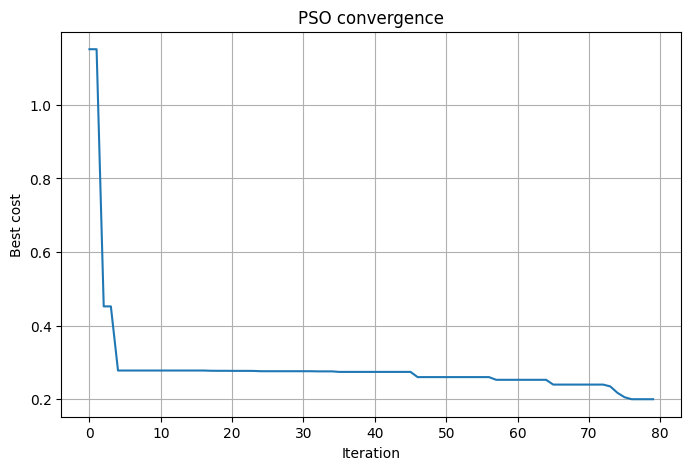

In [ ]:
kp, ki, kd = global_best

print("\nBEST PARAMETERS:")

print("kp =", kp)
print("ki =", ki)
print("kd =", kd)

plt.figure(figsize=(8,5))

plt.plot(history)

plt.xlabel("Iteration")
plt.ylabel("Best cost")

plt.title("PSO convergence")

plt.grid()

plt.show()

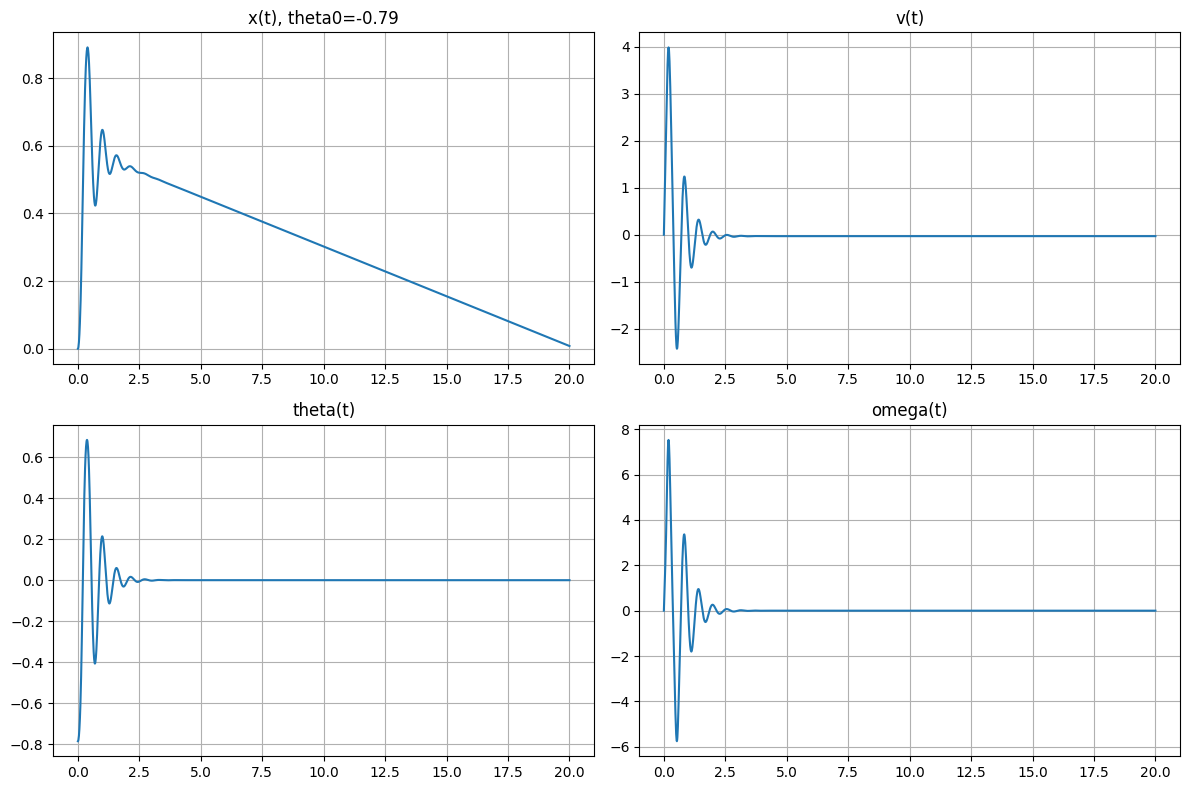

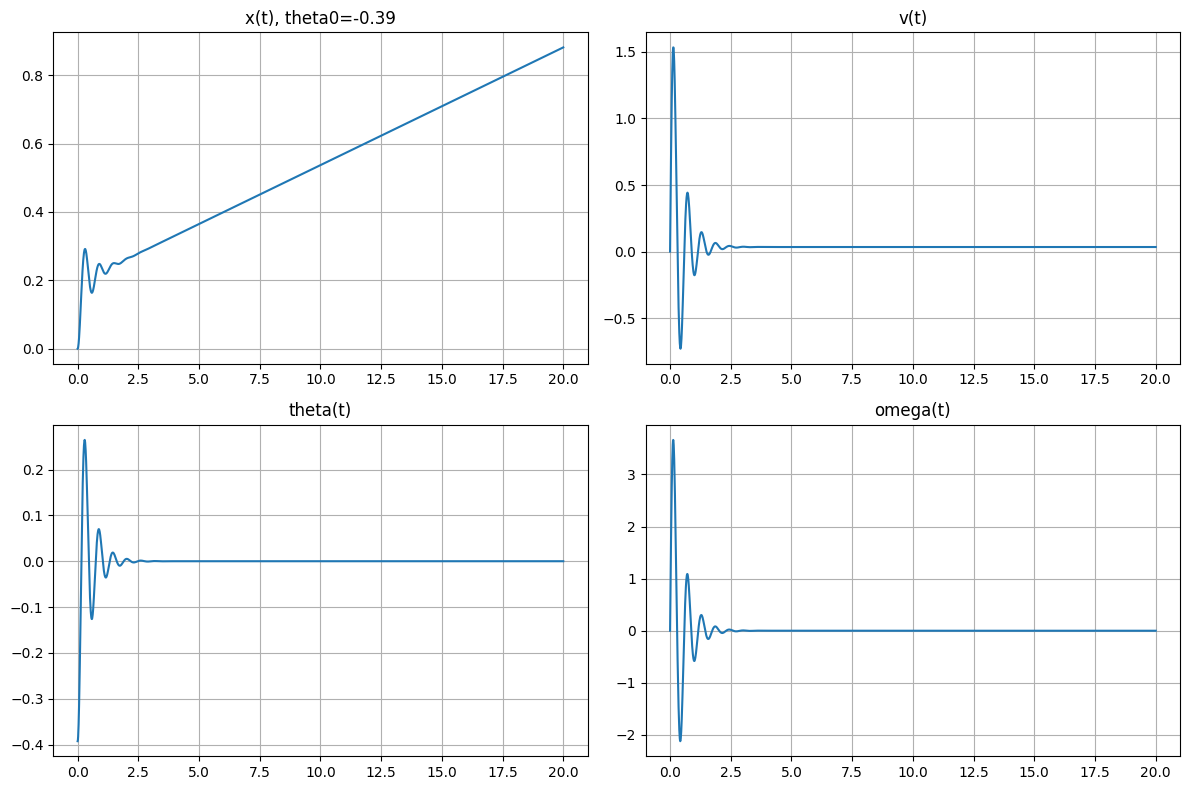

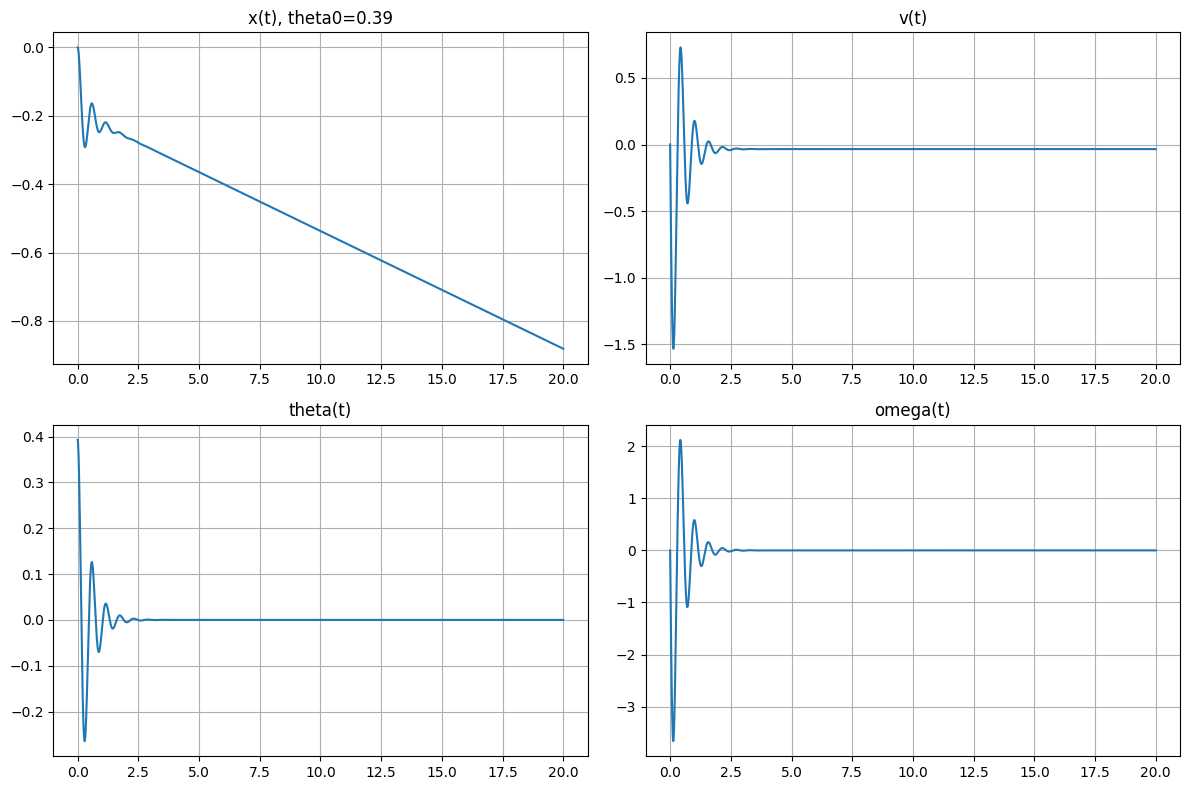

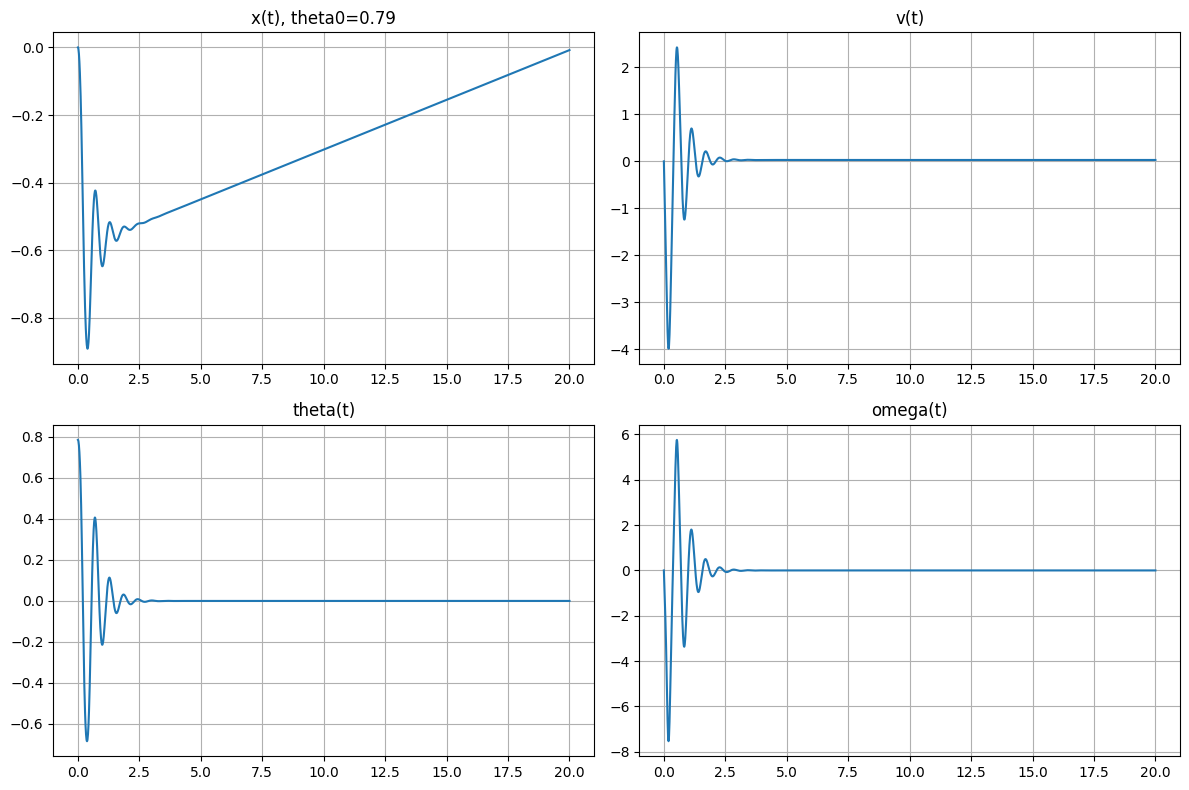

In [ ]:
theta_values = [
    -np.pi/4,
    -np.pi/8,
     np.pi/8,
     np.pi/4
]

for theta0 in theta_values:

    sol = simulate(
        kp,
        ki,
        kd,
        theta0
    )

    t = sol.t

    x = sol.y[0]
    v = sol.y[1]
    theta = sol.y[2]
    omega = sol.y[3]

    plt.figure(figsize=(12,8))

    plt.subplot(2,2,1)
    plt.plot(t, x)
    plt.title(f"x(t), theta0={theta0:.2f}")
    plt.grid()

    plt.subplot(2,2,2)
    plt.plot(t, v)
    plt.title("v(t)")
    plt.grid()

    plt.subplot(2,2,3)
    plt.plot(t, theta)
    plt.title("theta(t)")
    plt.grid()

    plt.subplot(2,2,4)
    plt.plot(t, omega)
    plt.title("omega(t)")
    plt.grid()

    plt.tight_layout()

    plt.show()